# Assignment 3
### Due 9/21. Do four of five.

# Name: Erin Siedlecki

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
nhanes = pd.read_csv('./data/nhanes_data_17_18.csv', low_memory=False)

In [3]:
nhanes['healthcondition_na'] = nhanes['GeneralHealthCondition'].isna() 
nhanes['healthcondition_na'].value_counts()

healthcondition_na
False    5964
True     2402
Name: count, dtype: int64

In [4]:
nhanes['diet_na'] = nhanes['HowHealthyIsTheDiet'].isna() 
nhanes['diet_na'].value_counts()

diet_na
False    5826
True     2540
Name: count, dtype: int64

The two categorical variables I selected were 'GeneralHealthCondition' and 'HowHealthyIsTheDiet'. Upon review, there were 2,402 NAs for 'GeneralHealthCondition' and 2,540 NAs for 'HowHealthyIsTheDiet'. When you calculate the proportion of NAs for each of these variables, you get about 29% for 'GeneralHealthCondition' and about 30% for 'HowHealthyIsTheDiet'. These are high percentages of NAs for these variables, which illustrates that our data is not very clean.

In [5]:
pd.crosstab(nhanes['HowHealthyIsTheDiet'],nhanes['GeneralHealthCondition']) # raw

GeneralHealthCondition,Excellent,Fair or,Good,Poor?,Very good
HowHealthyIsTheDiet,,,,,
Excellent,141,45,109,5,103
Fair,54,516,631,57,200
Good,120,318,1109,43,537
Poor,11,167,114,53,30
Very good,174,87,298,11,482


In [6]:
pd.crosstab(nhanes['HowHealthyIsTheDiet'], nhanes['GeneralHealthCondition'], normalize='columns') # proportions

GeneralHealthCondition,Excellent,Fair or,Good,Poor?,Very good
HowHealthyIsTheDiet,,,,,
Excellent,0.282,0.039718,0.048209,0.029586,0.076183
Fair,0.108,0.455428,0.279080,0.337278,0.147929
Good,0.240,0.280671,0.490491,0.254438,0.397189
Poor,0.022,0.147396,0.050420,0.313609,0.022189
Very good,0.348,0.076787,0.131800,0.065089,0.356509


The contingency tables show us what we would expect for a correlation between diet and health condition - that a healthier diet correlates with a better general health condition. 

We can see an example of this by looking at the Excellent 'GeneralHealthCondition' category. Of the 500 people who have Excellent 'GeneralHealthCondition', the large majority have Excellent or Very good 'HowHealthyIsTheDiet'. We can also see the other end of the spectrum, of the 169 people who have Poor 'GeneralHealthCondition', the large majority have Poor or Fair 'HowHealthyIsTheDiet'.

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [7]:
nhanes['healthcondition_na'].value_counts()

healthcondition_na
False    5964
True     2402
Name: count, dtype: int64

In [8]:
nhanes['weight_na'] = nhanes['WeightKg'].isna() 
nhanes['weight_na'].value_counts()

weight_na
False    8242
True      124
Name: count, dtype: int64

The categorical variable I selected was 'GeneralHealthCondition' and the numeric was 'WeightKg'. Upon review, there were 2,402 NAs for 'GeneralHealthCondition' and 124 NAs for 'WeightKg'. The proportion of NAs for 'GeneralHealthCondition', like we saw in the last question, is about 29%. The proportion of NAs for 'WeightKg' is much lower at about 1.5%. This illustrates that our data for 'WeightKg is much cleaner than for 'GeneralHealthCondition.

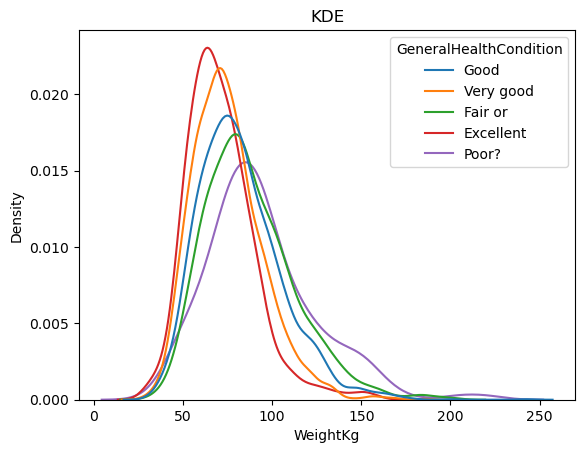

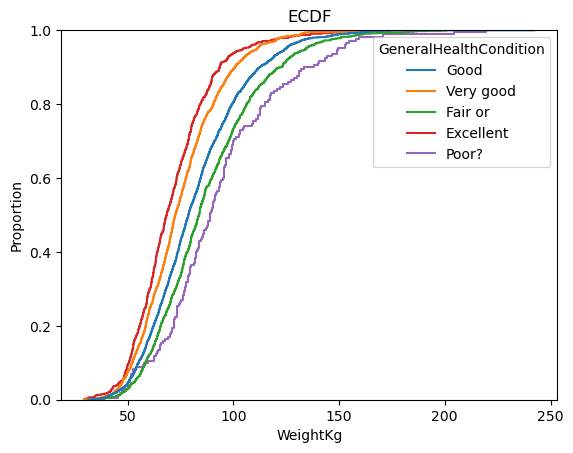

WeightKg                                             \
                          count       mean        std   min     25%    50%   
GeneralHealthCondition                                                       
Excellent                 612.0  71.188399  19.169784  29.4  58.475  68.45   
Fair or                  1152.0  87.445920  25.361884  33.4  69.300  83.80   
Good                     2431.0  81.973015  23.289469  31.4  65.200  78.70   
Poor?                     170.0  93.521176  30.141754  36.8  73.550  89.05   
Very good                1534.0  75.136441  19.746632  29.3  60.700  72.50   

                                        
                            75%    max  
GeneralHealthCondition                  
Excellent                80.725  158.7  
Fair or                 101.700  200.9  
Good                     95.200  242.6  
Poor?                   109.275  219.6  
Very good                85.800  185.0

In [9]:
health = 'GeneralHealthCondition'
sns.kdeplot( data=nhanes, x='WeightKg', hue=health, common_norm=False ).set(title='KDE')
plt.show()
sns.ecdfplot( data=nhanes, x='WeightKg', hue=health).set(title='ECDF')
plt.show()
nhanes.loc[:,['WeightKg', health]].groupby(health).describe()

The kernel density plot shows what we would expect - that people with better general health condition weigh less. When looking at the peaks of the curves, we see that concentration of data goes in order from left to right of best health condition to worst health condition (i.e.excellent, very good, good, fair, poor), which coincides with lower weights to higher weights. We can also see that the width of the curves (spread) increases from left to right (better health to worse health), with the poor general health condition having the largest variance of weight out of all the health conditions. This larger spread might be because someone with a serious illness might have lost a significant amount of weight due to their illness, or someone diagnosed with the disease of obesity would have a higher weight. That could be a reason that there is a wider variance of weight for individuals with poor general health condition. Overall, the KDE illustrates the general pattern of lower weight, better general health condition.

When looking at the descriptive table, we can see that individuals with Excellent 'GeneralHealthCondition' have the lowest mean and median 'WeightKg', and that individuals with Poor 'GeneralHealthCondition' have the highest mean and median 'WeightKg'. This further support the pattern we are seeing that individuals who weigh less have better general health condition.

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

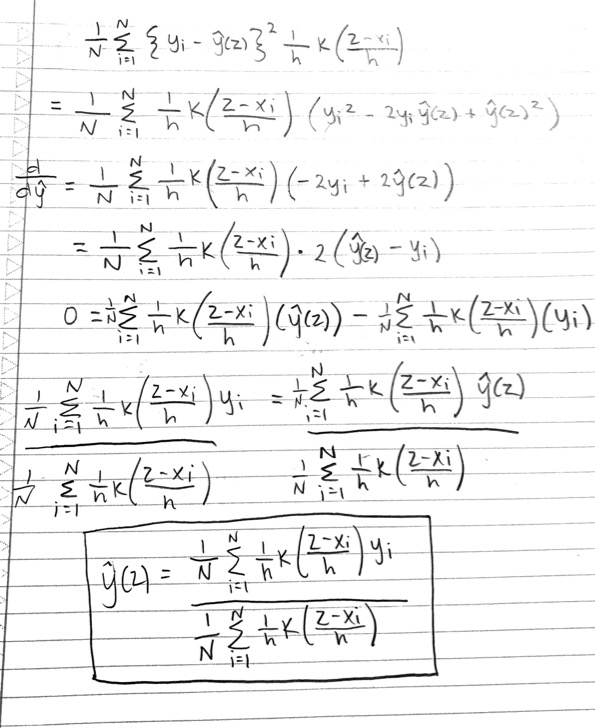

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

<Axes: xlabel='SleepHoursWeekdaysOrWorkdays', ylabel='BodyMassIndexKgm2'>

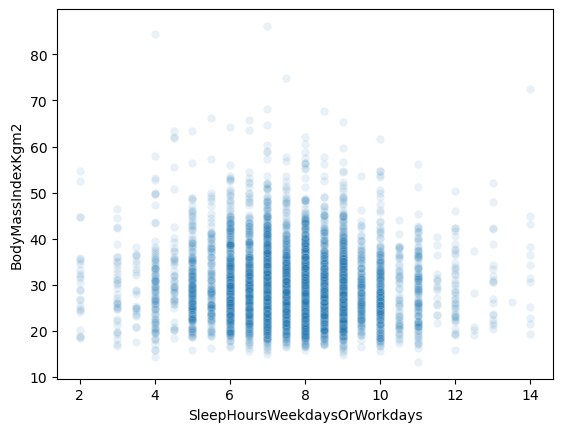

In [10]:
sns.scatterplot(data=nhanes, y='BodyMassIndexKgm2', x='SleepHoursWeekdaysOrWorkdays',alpha=.1)

,BodyMassIndexKgm2
SleepHoursWeekdaysOrWorkdays,
2.0,31.288000
3.0,29.075676
3.5,28.469565
4.0,30.106931
4.5,33.089583
5.0,29.888318
5.5,31.137600
6.0,30.215844
6.5,30.262637


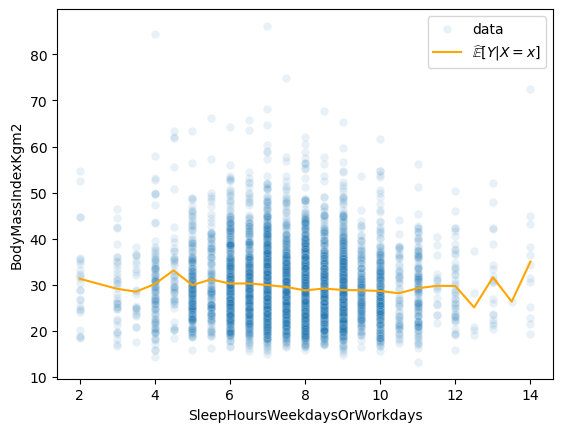

In [11]:
means = nhanes.loc[:,['BodyMassIndexKgm2','SleepHoursWeekdaysOrWorkdays']].groupby('SleepHoursWeekdaysOrWorkdays').mean()
sns.scatterplot(data=nhanes, y='BodyMassIndexKgm2', x='SleepHoursWeekdaysOrWorkdays',alpha=.1, label='data')
sns.lineplot(data=means, x='SleepHoursWeekdaysOrWorkdays',y='BodyMassIndexKgm2',color='orange', label='$\\widehat{\\mathbb{E}}[Y|X=x]$')

means

This relationship is not plausibly causal. Because 'SleepHoursWeekdaysOrWorkdays' is discrete, our scatterplot presents as a series of vertical lines since many data points have the same x-values but different y-values. From the scatterplot, we can see that the majority of sleep hours fall within the 5-10 hour range, and that the BMI is mostly between 18-40 Kgm2. The BMI values become much more spread out below 4 hours of sleep and above 12 hours of sleep.

Typically, we would see that hours of sleep does impact someone's overall health. Thus, this could impact a person's BMI as it can help determine the risk of health issues associated with obesity. Other variables that could have an impact on 'BodyMassIndexKgm2' would be things such as chronic illness, diet, exercise, mental health, or age. As there are many other variables that have an impact on BMI, we can determine that there are potential threats to causal identification of the effect of SleepHoursWeekdaysOrWorkdays' on 'BodyMassIndexKgm2'.

Regardless of the threat to causal identification, we can use the model above to predict 'BodyMassIndexKgm2' given 'SleepHoursWeekdaysOrWorkdays'. This is because the CEF shows us the average BMI for each hour of sleep, which means this model is useful in determining the general trend of BMI versus sleep hours. Therefore, we can still use our model to predict BMI given sleep hours.